In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

| Parameter         | Meaning                              |
| ----------------- | ------------------------------------ |
| `n_samples=500`   | Number of data points                |
| `centers=3`       | Number of clusters                   |
| `cluster_std=4`   | Spread of each cluster               |
| `random_state=42` | Makes random generation reproducible |

# K-Means Algorithm

In [28]:
X, y = make_blobs(n_samples=500, centers=3, cluster_std=0.56,random_state=42)

In [29]:
# convert X into dataset
df = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])

In [30]:
df.head()

,Feature_1,Feature_2
0,-6.236034,-7.273888
1,3.129622,1.942765
2,5.866168,1.520523
3,-2.728778,8.194718
4,5.312559,1.744647


In [31]:
# Standard scaling
scaler = StandardScaler()
X_scaled=scaler.fit_transform(df)

In [32]:
inertia = []
K_range = range(1,11)

In [33]:
for k in K_range:
    model = KMeans(n_clusters=k,random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

In [34]:
inertia

[999.9999999999999,
 296.7101192125853,
 10.094668178447847,
 8.504016169818058,
 7.199948557519169,
 6.236023814772291,
 5.523481298982425,
 4.973774267362169,
 4.4125739691338595,
 4.1528268934337405]

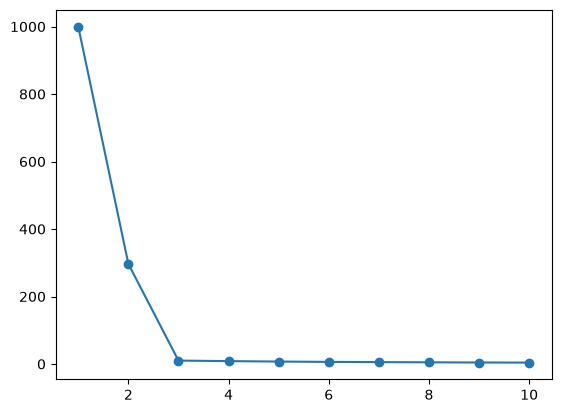

In [35]:
plt.plot(K_range, inertia, marker="o")

In [36]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [37]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [38]:
df["cluster"] = cluster_labels
df.head()

,Feature_1,Feature_2,cluster
0,-6.236034,-7.273888,1
1,3.129622,1.942765,0
2,5.866168,1.520523,0
3,-2.728778,8.194718,2
4,5.312559,1.744647,0


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

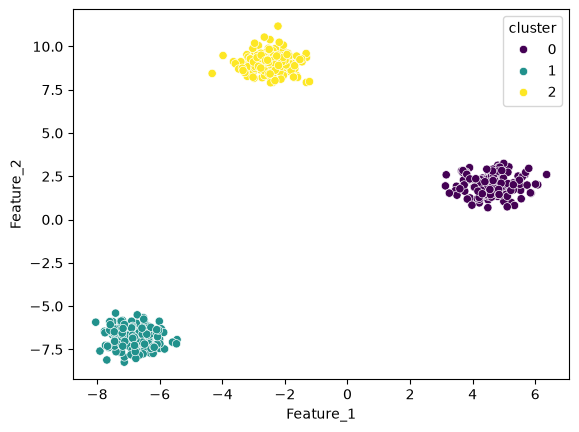

In [39]:
sns.scatterplot(x=df["Feature_1"],
                y=df["Feature_2"],
                hue=df["cluster"],
                palette="viridis")